[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ddumu/dourado-minguell-eml-mia-um-p1/blob/main/Entornos_Complejos/MonteCarloTodasLasVisitas.ipynb)

## **1. SARSA Semi Gradiente para el entorno Frozen Lake**

In [1]:
# %%capture
#@title Instalamos gym
## Instalación de algunos paquetes.
#!apt-get update
## Para usar gymnasium[box2d]
!apt install swig numpy matplotlib gymnasium
!pip install "gymnasium[toy-text]"
#!pip install gymnasium[box2d]

"apt" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Liberias

In [ ]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import os

from src.experiment.sarsa_functions import pi_star_from_Q, semi_gradient_sarsa, plot, plot_episodes_length, plot_policy_episodes

## Reproducibilidad

In [3]:
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija
# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla
# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

name = 'FrozenLake-v1' # Cambiar según el entorno deseado

## Creación de entorno

In [4]:
#@title Importamos el lago helado
env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode="ansi", reward_schedule=(1, 0, 0)) # No resbaladizo para entender mejor los resultados.
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode="ansi", reward_schedule=(1, 0, 0)) # No resbaladizo para entender mejor los resultados.
env4.reset(seed=seed)
env8.reset(seed=seed)

(0, {'prob': 1})


## Acciones

In [5]:
LEFT, DOWN, RIGHT, UP = 0, 1, 2, 3

## Experimentación

### Ejecución entorno 4x4

In [6]:
w4, Q, list_stats, list_episodes_length = semi_gradient_sarsa(
    env4,
    num_episodes=50000,
    epsilon=1.0,
    decay=True,
    discount_factor=0.99,
    alpha=0.01
)

 11%|█         | 5479/50000 [00:01<00:11, 3865.25it/s]

success rate: 0.4368, epsilon: 0.2000


 21%|██▏       | 10746/50000 [00:02<00:09, 4244.62it/s]

success rate: 0.6477, epsilon: 0.1000


 31%|███▏      | 15673/50000 [00:03<00:09, 3596.39it/s]

...

 81%|████████  | 40309/50000 [00:11<00:02, 3270.75it/s]

success rate: 0.8760, epsilon: 0.0250


 91%|█████████ | 45543/50000 [00:12<00:00, 4657.80it/s]

success rate: 0.8873, epsilon: 0.0222


100%|██████████| 50000/50000 [00:13<00:00, 3633.58it/s]


#### Evaluación

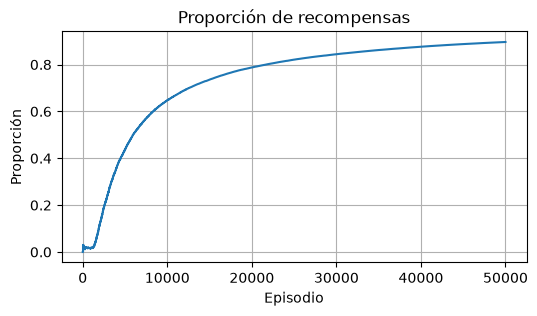

Máxima proporcion: 0.89632


In [7]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

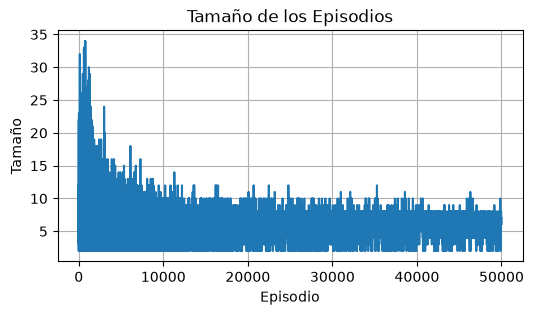

Máximo tamaño de episodio: 34


In [8]:
plot_episodes_length(list_episodes_length)
print(f"Máximo tamaño de episodio:", max(list_episodes_length))

In [9]:
pi, actions = pi_star_from_Q(env4, Q)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env4.render())

Política óptima obtenida
 [[0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 0. 0.]] 
 Acciones 1, 1, 2, 2, 1, 2,  
 Para el siguiente grid
   (Right)
SFFF
FHFH
FFFH
HFFG



### Ejecución entorno 8x8

In [10]:
w8, Q, list_stats, list_episodes_length = semi_gradient_sarsa(
    env8,
    num_episodes=50000,
    epsilon=1.0,
    decay=True,
    discount_factor=0.99,
    alpha=0.01
)

 11%|█         | 5307/50000 [00:04<00:24, 1801.12it/s]

success rate: 0.4572, epsilon: 0.2000


 20%|██        | 10182/50000 [00:07<00:20, 1948.46it/s]

success rate: 0.6677, epsilon: 0.1000


 31%|███       | 15330/50000 [00:10<00:16, 2058.44it/s]

...

 80%|████████  | 40247/50000 [00:22<00:04, 1974.92it/s]

success rate: 0.8895, epsilon: 0.0250


 91%|█████████ | 45332/50000 [00:25<00:02, 1965.11it/s]

success rate: 0.9000, epsilon: 0.0222


100%|██████████| 50000/50000 [00:27<00:00, 1799.12it/s]


#### Evaluación

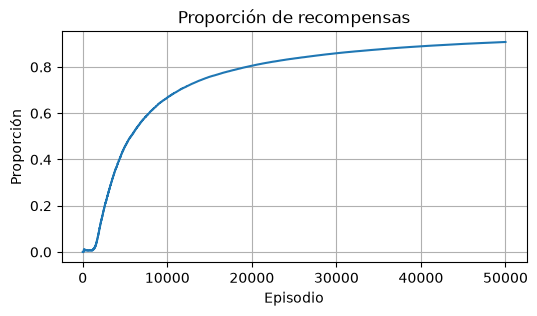

Máxima proporcion: 0.90812


In [11]:
plot(list_stats)
print(f"Máxima proporcion: {list_stats[-1]}")

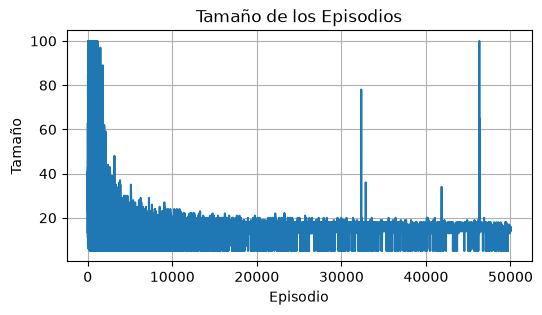

Máximo tamaño de episodio: 100


In [12]:
plot_episodes_length(list_episodes_length)
print(f"Máximo tamaño de episodio:", max(list_episodes_length))

In [13]:
# @title Política final 8x8
LEFT, DOWN, RIGHT, UP = 0,1,2,3
pi, actions = pi_star_from_Q(env8, Q)

print("Política óptima obtenida\n", pi, f"\n Acciones {actions} \n Para el siguiente grid\n", env8.render())

Política óptima obtenida
 [[0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 2. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]] 
 Acciones 2,

In [15]:
plot_policy_episodes(Q, 1)